# Análise Exploratória - Dataset Amazon.csv


---
## 1. Importação das Bibliotecas e Leitura de Dados

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Melhoria da exibição e performance inicial
pd.set_option('display.max_columns', None)

# Carregamento do dataset
df = pd.read_csv('Amazon.csv')
df.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


## 2. Dimensão e Volumes
Identificando a quantia de instâncias (linhas) e características (colunas).

In [2]:
print(f'Registros (Linhas): {df.shape[0]}')
print(f'Atributos (Colunas): {df.shape[1]}')

# Verificação da tipagem dos dados
df.info()

Registros (Linhas): 100000
Atributos (Colunas): 20
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   OrderID        100000 non-null  str    
 1   OrderDate      100000 non-null  str    
 2   CustomerID     100000 non-null  str    
 3   CustomerName   100000 non-null  str    
 4   ProductID      100000 non-null  str    
 5   ProductName    100000 non-null  str    
 6   Category       100000 non-null  str    
 7   Brand          100000 non-null  str    
 8   Quantity       100000 non-null  int64  
 9   UnitPrice      100000 non-null  float64
 10  Discount       100000 non-null  float64
 11  Tax            100000 non-null  float64
 12  ShippingCost   100000 non-null  float64
 13  TotalAmount    100000 non-null  float64
 14  PaymentMethod  100000 non-null  str    
 15  OrderStatus    100000 non-null  str    
 16  City           100000 non-null  str

## 3. Avaliação de Qualidade e Integridade (Missing Values & Duplicados)

In [3]:
print('--- Valores Nulos por Coluna ---')
print(df.isnull().sum())

print('\n--- Total de Registros Duplicados ---')
print(df.duplicated().sum())

--- Valores Nulos por Coluna ---
OrderID          0
OrderDate        0
CustomerID       0
CustomerName     0
ProductID        0
ProductName      0
Category         0
Brand            0
Quantity         0
UnitPrice        0
Discount         0
Tax              0
ShippingCost     0
TotalAmount      0
PaymentMethod    0
OrderStatus      0
City             0
State            0
Country          0
SellerID         0
dtype: int64

--- Total de Registros Duplicados ---
0


## 4. Análise Crítica (Inconsistências Identificadas)
Exemplo de anomalia na natureza do dado (Sintético ou Ruído): Drone classificado como Books e Washington DC alocado na Índia.

In [4]:
# Check de anomalias espaciais clássicas detectadas
anomalia_geo = df[(df['State'] == 'DC') & (df['Country'] == 'India')]
display(anomalia_geo[['City', 'State', 'Country']].head())

# Check de anomalias logísticas detectadas
anomalia_cat = df[(df['ProductName'].str.contains('Drone', case=False, na=False)) & (df['Category'] == 'Books')]
display(anomalia_cat[['ProductName', 'Category']].head())

,City,State,Country
0,Washington,DC,India
145,Washington,DC,India
255,Washington,DC,India
273,Washington,DC,India
311,Washington,DC,India


,ProductName,Category
0,Drone Mini,Books
48,Drone Mini,Books
101,Drone Mini,Books
341,Drone Mini,Books
344,Drone Mini,Books


## 5. Engenharia de Variáveis (Feature Engineering para Séries Temporais)
A conversão da data (OrderDate) é obrigatória para a manipulação dos timeseries de forma nativa e resample.

In [5]:
# Convertendo para datetime nativo do Pandas
df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce')

# Criando views temporais ricas
df['Ano'] = df['OrderDate'].dt.year
df['Mes'] = df['OrderDate'].dt.month
df['DiaDaSemana'] = df['OrderDate'].dt.day_name()

display(df[['OrderDate', 'Ano', 'Mes', 'DiaDaSemana']].sample(5))

,OrderDate,Ano,Mes,DiaDaSemana
11208,2023-08-18,2023,8,Friday
26322,2020-07-19,2020,7,Sunday
49559,2021-08-25,2021,8,Wednesday
50446,2024-02-21,2024,2,Wednesday
55172,2024-04-14,2024,4,Sunday


## 6. Distribuição Financeira / Outliers
É importante investigar comportamento antes de modelos preditivos.

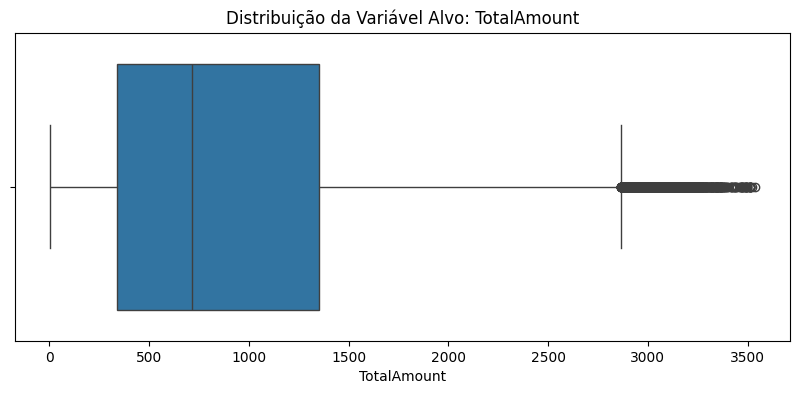

,count,mean,std,min,25%,50%,75%,max
UnitPrice,100000.0,302.905748,171.840797,5.00,154.19,303.070,451.500,599.99
Discount,100000.0,0.074226,0.082583,0.00,0.00,0.050,0.100,0.30
Tax,100000.0,68.468902,74.131180,0.00,15.92,45.250,96.060,538.46
ShippingCost,100000.0,7.406660,4.324057,0.00,3.68,7.300,11.150,15.00
TotalAmount,100000.0,918.256479,724.508332,4.27,340.89,714.315,1349.765,3534.98


In [6]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['TotalAmount'])
plt.title('Distribuição da Variável Alvo: TotalAmount')
plt.show()

df[['UnitPrice', 'Discount', 'Tax', 'ShippingCost', 'TotalAmount']].describe().T